# UCS761 – Deep Learning Lab 3
## Logistic Regression as a Soft Decision Model

### Objective
To implement Logistic Regression from scratch and understand how it produces probabilistic outputs instead of hard decisions like the Perceptron.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [27]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("glass.csv")
df.head()

Saving glass.csv to glass (2).csv


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [28]:
df.shape

(214, 10)

In [29]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [30]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Dataset Understanding

### What this step does:
- Displays dataset structure, column names, and sample rows.

### Why it is needed:
- To identify input features and output column.
- To check whether all columns are numeric.
- To verify if any column (like ID) should be removed.

In [31]:
df["y"] = (df["Type"] == 1).astype(int)
df = df.drop(columns=["Type"])
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,y
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Binary Conversion

### What this step does:
- Converts multi-class glass types into binary labels.
- Type 1 → 1 (positive class)
- All others → 0 (negative class)

### Why it is needed:
- Logistic Regression in this lab is implemented for binary classification.
- Simplifies the learning problem.

In [32]:
X = df.drop(columns=["y"]).values
y = df["y"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (214, 9)
Shape of y: (214,)


## Feature-Label Separation

### What this step does:
- Separates inputs (X) from output labels (y).

### Why it is needed:
- Models learn from input features to predict outputs.
- Clear separation ensures correct training.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 171
Testing samples: 43


## Train-Test Split

### What this step does:
- Splits dataset into training (80%) and testing (20%).

### Why it is needed:
- To evaluate model performance on unseen data.
- Prevents overfitting and false confidence.

In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Feature Scaling

### What this step does:
- Standardizes features to have mean 0 and variance 1.

### Why it is needed:
- Features have different numeric ranges.
- Prevents sigmoid saturation.
- Ensures stable gradient descent updates.

In [35]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## Sigmoid Function

### What this step does:
- Converts linear score (z) into probability between 0 and 1.

### Why it is needed:
- Step function gives only hard decisions.
- Sigmoid preserves uncertainty and confidence.

In [36]:
def predict_proba(X, w, b):
    z = X @ w + b
    return sigmoid(z)

In [37]:
def loss(y, p):
    return -np.mean(y*np.log(p + 1e-8) + (1-y)*np.log(1-p + 1e-8))

## Binary Cross-Entropy Loss

### What this step does:
- Measures how wrong the predicted probabilities are.

### Why it is needed:
- Penalizes confident wrong predictions heavily.
- Guides gradient descent to improve model confidence correctly.

In [38]:
def update_weights(X, y, w, b, lr):
    p = predict_proba(X, w, b)
    error = p - y

    w = w - lr * (X.T @ error) / len(y)
    b = b - lr * np.mean(error)

    return w, b

## Weight Update (Gradient Descent)

### What this step does:
- Adjusts weights and bias using prediction error.

### Why it is needed:
- Reduces loss gradually.
- Helps model learn correct decision boundary.

In [39]:
w = np.zeros(X_train.shape[1])
b = 0.0
lr = 0.1
epochs = 100

losses = []

for i in range(epochs):
    p = predict_proba(X_train, w, b)
    losses.append(loss(y_train, p))
    w, b = update_weights(X_train, y_train, w, b, lr)

print("Training completed.")

Training completed.


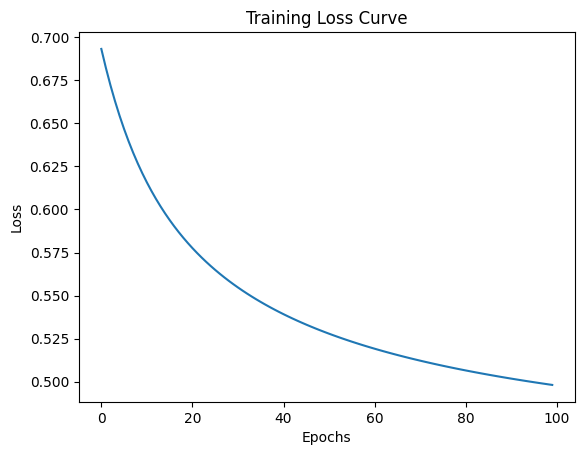

In [40]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [41]:
def predict_label(p, threshold=0.5):
    return (p >= threshold).astype(int)

In [42]:
p_test = predict_proba(X_test, w, b)

y_pred_05 = predict_label(p_test, 0.5)
y_pred_07 = predict_label(p_test, 0.7)

print("Accuracy (threshold=0.5):", accuracy_score(y_test, y_pred_05))
print("Accuracy (threshold=0.7):", accuracy_score(y_test, y_pred_07))

Accuracy (threshold=0.5): 0.8604651162790697
Accuracy (threshold=0.7): 0.7209302325581395


## Final Analysis

### How this differs from Perceptron
The Perceptron uses a step function and produces hard 0 or 1 outputs. Logistic Regression replaces the step function with a sigmoid function, producing probabilities instead of forced decisions.

### Why sigmoid matters
Sigmoid provides a smooth transition near the decision boundary. It preserves uncertainty and allows interpretation of model confidence.

### What problem still remains unsolved
The model still assumes a linear decision boundary. It cannot capture non-linear relationships in data and may struggle with complex patterns.
